# Complex Factory Simulation

This notebook sets up a multi-machine, multi-technician factory scenario and
demonstrates environment transitions, then compares **random** vs **heuristic**
policies by plotting cumulative reward curves.

In [1]:
import os, sys, warnings, logging
from contextlib import contextmanager

logging.disable(logging.WARNING)
warnings.filterwarnings("ignore")
os.environ["KATA_CONF_PATH"] = "/dev/null/no_such_file.json"

@contextmanager
def quiet():
    old = sys.stdout
    sys.stdout = open(os.devnull, "w")
    try:
        yield
    finally:
        sys.stdout.close()
        sys.stdout = old

## 1. Factory config

We define a factory with:
- 2 CNC machines (with spindle + pump components, Weibull breakdown)
- 1 Assembly machine (with motor + bearing components)
- 4 technicians with different expertise levels
- Products following a CNC -> Assembly route

In [2]:
from kata.core.config import (
    KATAConfig, GymEnvConfig, GymRewardConfig, RewardComponentConfig,
    TechnicianConfig, MachineConfig, ProductConfig, ComponentConfig,
)
from kata.features.breakdown.config import WeibullBreakdownConfig, SimpleBreakdownConfig
from kata.scenario import ScenarioBuilder
from kata.env import KataEnv

cfg = KATAConfig(
    technicians={
        "expert": TechnicianConfig(
            name="expert",
            fatigue_lambda=0.005,
            fatigue_mu=0.08,
            knowledge_learning_rate=0.15,
        ),
        "generalist": TechnicianConfig(
            name="generalist",
            fatigue_lambda=0.01,
            fatigue_mu=0.05,
            knowledge_learning_rate=0.10,
        ),
        "junior_1": TechnicianConfig(
            name="junior_1",
            fatigue_lambda=0.02,
            fatigue_mu=0.03,
            knowledge_learning_rate=0.05,
        ),
        "junior_2": TechnicianConfig(
            name="junior_2",
            fatigue_lambda=0.02,
            fatigue_mu=0.03,
            knowledge_learning_rate=0.05,
        ),
    },
    machines={
        "cnc_1": MachineConfig(
            machine_type="CNC",
            process_time=200,
            components={
                "spindle": ComponentConfig(
                    component_id="spindle_0", component_type="spindle",
                    base_repair_time=90.0,
                    breakdown_model="weibull",
                    weibull_breakdown=WeibullBreakdownConfig(shape=2.5, scale=800.0),
                ),
                "pump": ComponentConfig(
                    component_id="pump_0", component_type="pump",
                    base_repair_time=40.0,
                    breakdown_model="weibull",
                    weibull_breakdown=WeibullBreakdownConfig(shape=3.0, scale=1200.0),
                ),
            },
        ),
        "cnc_2": MachineConfig(
            machine_type="CNC",
            process_time=200,
            components={
                "spindle": ComponentConfig(
                    component_id="spindle_1", component_type="spindle",
                    base_repair_time=90.0,
                    breakdown_model="weibull",
                    weibull_breakdown=WeibullBreakdownConfig(shape=2.5, scale=800.0),
                ),
            },
        ),
        "assembly": MachineConfig(
            machine_type="Assembly",
            process_time=120,
            components={
                "motor": ComponentConfig(
                    component_id="motor_0", component_type="motor",
                    base_repair_time=50.0,
                    breakdown_model="weibull",
                    weibull_breakdown=WeibullBreakdownConfig(shape=2.5, scale=800.0),
                ),
                "bearing": ComponentConfig(
                    component_id="bearing_0", component_type="bearing",
                    base_repair_time=30.0,
                    breakdown_model="simple",
                    simple_breakdown=SimpleBreakdownConfig(
                        failure_prob_working=0.002,
                        failure_prob_idle=0.0002,
                    ),
                ),
            },
        ),
    },
    products={
        "precision_part": ProductConfig(route=["CNC", "Assembly"]),
    },
    gym=GymEnvConfig(
        max_episode_steps=500,
        max_sim_time=50_000.0,
        observation_representation="structured",
        reward=GymRewardConfig(
            assignment=RewardComponentConfig(enabled=True, coefficient=1.0),
            wait_time=RewardComponentConfig(enabled=True, coefficient=2.0),
            queue_size=RewardComponentConfig(enabled=True, coefficient=0.5),
            busy_technician=RewardComponentConfig(enabled=True, coefficient=1.5),
        ),
        assignment_reward=1.0,
    ),
)


def make_factory():
    return ScenarioBuilder(cfg).build()


print(f"Technicians: {list(cfg.technicians.keys())}")
print(f"Machines:    {list(cfg.machines.keys())}")
print(f"Products:    {list(cfg.products.keys())}")
print(f"Reward components: assignment, wait_time, queue_size, busy_technician")

Technicians: ['expert', 'generalist', 'junior_1', 'junior_2']
Machines:    ['cnc_1', 'cnc_2', 'assembly']
Products:    ['precision_part']
Reward components: assignment, wait_time, queue_size, busy_technician


## 2. Inspect transitions

Let's step through the environment and display the observation, reward, and info
for each transition to understand what the agent sees.

In [3]:
import numpy as np

with quiet():
    env = KataEnv(scenario_factory=make_factory, config=cfg.gym)
    obs, info = env.reset()

print("=== Initial observation ===")
for k, v in obs.items():
    print(f"  {k:25s} = {v}")
print(f"  {'sim_time':25s} = {info['sim_time']:.0f}")
print(f"  {'queue_size':25s} = {info['pending_queue_size']}")
print()

# Collect transitions inside quiet(), then print outside
transitions = []
with quiet():
    for step in range(10):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        transitions.append((step, action, reward, obs, info, terminated))
        if terminated or truncated:
            break

print("=== First 10 transitions ===")
for step, action, reward, obs, info, terminated in transitions:
    tech_busy = obs["technician_busy"]
    tech_fatigue = obs.get("technician_fatigue", np.zeros(4))
    print(
        f"  step={step:3d} | action=tech_{action} "
        f"| reward={reward:+7.3f} | t={info['sim_time']:8.0f} "
        f"| busy={tech_busy.tolist()} "
        f"| fatigue=[{', '.join(f'{f:.3f}' for f in tech_fatigue)}] "
        f"| queue={info['pending_queue_size']}"
    )
    if step < 3:
        print(f"          reward_breakdown = {info['reward_breakdown']}")

=== Initial observation ===
  sim_time                  = [429.]
  has_open_ticket           = [1]
  ticket_created_at         = [429.]
  ticket_machine_id         = [836.]
  technician_busy           = [0 0 0 0]
  technician_fatigue        = [0. 0. 0. 0.]
  pending_queue_size        = [0.]
  sim_time                  = 429
  queue_size                = 0

=== First 10 transitions ===
  step=  0 | action=tech_2 | reward= +1.000 | t=     697 | busy=[0, 0, 0, 0] | fatigue=[0.000, 0.000, 0.632, 0.000] | queue=0
          reward_breakdown = {'assignment': 1.0, 'wait_time': -0.0, 'queue_size': -0.0, 'busy_technician': 0.0}
  step=  1 | action=tech_3 | reward= +1.000 | t=     742 | busy=[0, 0, 0, 0] | fatigue=[0.000, 0.000, 0.632, 0.451] | queue=0
          reward_breakdown = {'assignment': 1.0, 'wait_time': -0.0, 'queue_size': -0.0, 'busy_technician': 0.0}
  step=  2 | action=tech_1 | reward= +1.000 | t=     969 | busy=[0, 0, 0, 0] | fatigue=[0.000, 0.330, 0.632, 0.451] | queue=0
          

## 3. Token-level transitions

The same transitions viewed as key-value tokens, showing how
the observation is structured for a Transformer agent.

In [4]:
token_cfg = cfg.gym.model_copy(update={
    "observation_representation": "tokens",
    "observation_mode": "factory_level",
    "include_technician_fatigue_tokens": True,
    "include_technician_knowledge_tokens": True,
    "token_observation_length": 128,
})

with quiet():
    env_tok = KataEnv(scenario_factory=make_factory, config=token_cfg)
    obs, _ = env_tok.reset()

tokens = obs["tokens"]
# Print tokens as key-value pairs
print("Initial token observation (non-PAD):")
non_pad = [t for t in tokens if t != "<PAD>"]
i = 0
while i < len(non_pad):
    tok = non_pad[i]
    # Keys are uppercase or TECH_ prefixed; values follow
    if i + 1 < len(non_pad) and tok.isupper() or tok.startswith("TECH_"):
        val = non_pad[i + 1] if i + 1 < len(non_pad) else "?"
        print(f"  {tok:30s} -> {val}")
        i += 2
    else:
        print(f"  {tok}")
        i += 1

print(f"\nTotal tokens (incl. PAD): {len(tokens)}")
print(f"Non-PAD tokens: {len(non_pad)}")

Initial token observation (non-PAD):
  OBS_MODE                       -> factory_level
  SIM_TIME                       -> T_200_500
  HAS_TICKET                     -> TRUE
  TICKET_AGE                     -> T_0_50
  TICKET_MACHINE_TYPE            -> CNC
  MACHINE_TYPE                   -> CNC
  MACHINE_BROKEN                 -> TRUE
  MACHINE_PROCESSING             -> TRUE
  MACHINE_TOTAL_PROCESSED        -> C_1
  MACHINE_INPUT_BUF              -> C_6_10
  MACHINE_OUTPUT_BUF             -> C_0
  FACTORY_MACHINES               -> C_2_3
  FACTORY_BROKEN                 -> C_1
  FACTORY_PROCESSING             -> C_2_3
  FACTORY_PRODUCED               -> C_2_3
  FACTORY_QUEUE                  -> C_0
  TECH_0                         -> BUSY
  FALSE                          -> TECH_0
  FATIGUE                        -> R_0
  TECH_0                         -> KNOWLEDGE
  R_0                            -> TECH_1
  BUSY                           -> FALSE
  TECH_1                         -> F

## 4. Policy comparison: Random vs Heuristics

We define three policies and run each for a full episode, collecting
per-step rewards for comparison:

1. **Random** - uniform random technician selection
2. **Least-busy** - pick a non-busy tech (random tiebreak)
3. **Least-fatigued** - pick the non-busy tech with lowest fatigue

In [5]:
def random_policy(obs, n_techs):
    return np.random.randint(n_techs)


def least_busy_policy(obs, n_techs):
    busy = obs["technician_busy"]
    free = np.where(busy == 0)[0]
    if len(free) > 0:
        return int(np.random.choice(free))
    return np.random.randint(n_techs)


def least_fatigued_policy(obs, n_techs):
    busy = obs["technician_busy"]
    fatigue = obs.get("technician_fatigue", np.zeros(n_techs, dtype=np.float32))
    scores = fatigue + busy * 100.0
    return int(np.argmin(scores))


def run_episode(env_cfg, policy_fn, seed=42):
    """Run one episode, return per-step rewards."""
    with quiet():
        env = KataEnv(scenario_factory=make_factory, config=env_cfg)
        obs, info = env.reset(seed=seed)
        n_techs = len(env.dispatcher.techs)
        rewards = []
        for _ in range(env_cfg.max_episode_steps):
            action = policy_fn(obs, n_techs)
            obs, reward, terminated, truncated, info = env.step(action)
            rewards.append(reward)
            if terminated or truncated:
                break
    return rewards


policies = {
    "Random": random_policy,
    "Least-busy": least_busy_policy,
    "Least-fatigued": least_fatigued_policy,
}

results = {}
for name, fn in policies.items():
    rewards = run_episode(cfg.gym, fn, seed=42)
    results[name] = rewards
    print(
        f"{name:20s} | steps={len(rewards):4d} "
        f"| total={sum(rewards):+8.2f} "
        f"| mean={np.mean(rewards):+.4f}"
    )

Random               | steps=  92 | total=  +65.00 | mean=+0.7065
Least-busy           | steps=  92 | total=  +92.00 | mean=+1.0000
Least-fatigued       | steps=  93 | total=  +93.00 | mean=+1.0000


## 5. Plot: Cumulative reward over episode steps

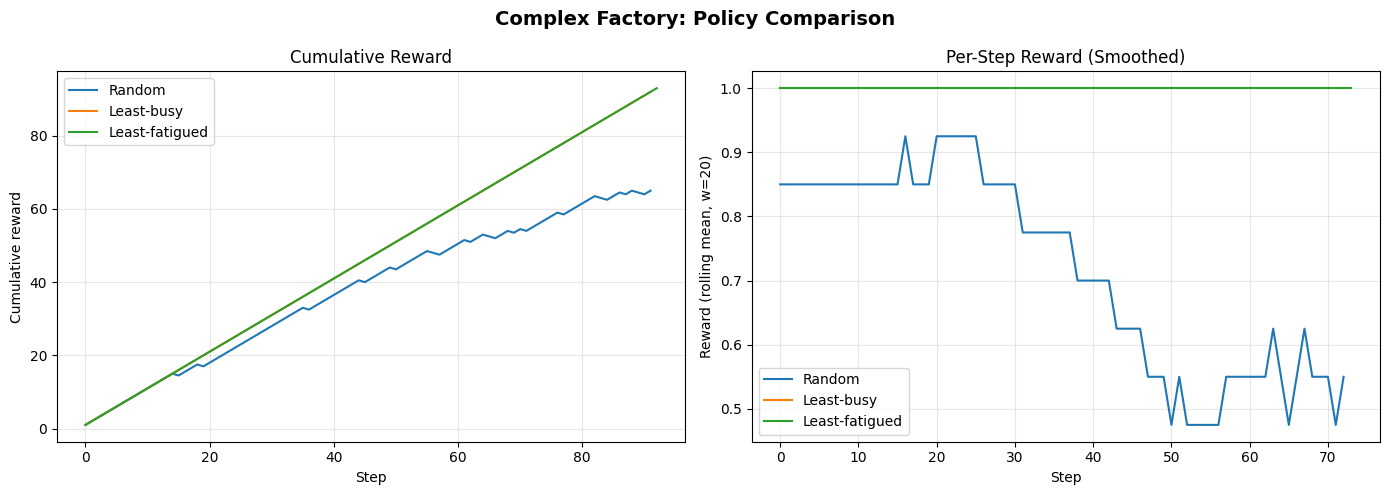

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Cumulative reward ---
ax = axes[0]
for name, rewards in results.items():
    cumulative = np.cumsum(rewards)
    ax.plot(cumulative, label=name, linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("Cumulative reward")
ax.set_title("Cumulative Reward")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Rolling mean reward (window=20) ---
ax = axes[1]
window = 20
for name, rewards in results.items():
    if len(rewards) >= window:
        rolling = np.convolve(rewards, np.ones(window) / window, mode="valid")
        ax.plot(rolling, label=name, linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel(f"Reward (rolling mean, w={window})")
ax.set_title("Per-Step Reward (Smoothed)")
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle("Complex Factory: Policy Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Plot: Technician fatigue over time

Run the least-fatigued policy again but this time track per-tech fatigue.

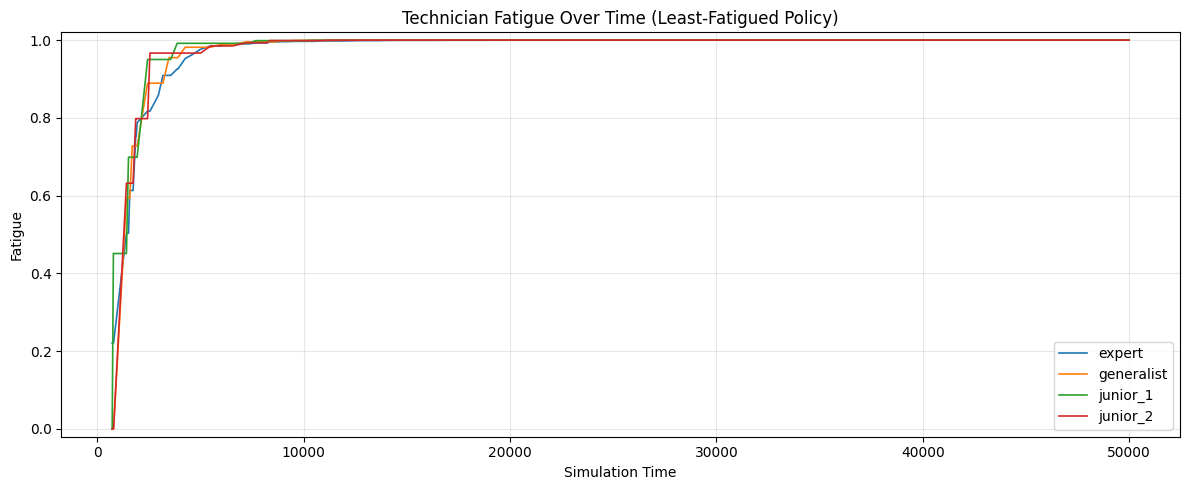

In [7]:
with quiet():
    env_f = KataEnv(scenario_factory=make_factory, config=cfg.gym)
    obs, info = env_f.reset(seed=42)
    n_techs = len(env_f.dispatcher.techs)
    tech_names = [t.name for t in env_f.dispatcher.techs]

    fatigue_history = []
    time_history = []

    for _ in range(cfg.gym.max_episode_steps):
        action = least_fatigued_policy(obs, n_techs)
        obs, reward, terminated, truncated, info = env_f.step(action)
        fatigue_history.append(obs.get("technician_fatigue", np.zeros(n_techs)).copy())
        time_history.append(info["sim_time"])
        if terminated or truncated:
            break

fatigue_arr = np.array(fatigue_history)

fig, ax = plt.subplots(figsize=(12, 5))
for i in range(n_techs):
    ax.plot(time_history, fatigue_arr[:, i], label=tech_names[i], linewidth=1.2)
ax.set_xlabel("Simulation Time")
ax.set_ylabel("Fatigue")
ax.set_title("Technician Fatigue Over Time (Least-Fatigued Policy)")
ax.legend()
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Multiple seeds: statistical comparison

Run each policy over 5 random seeds and compare distributions.

In [8]:
seeds = [0, 1, 2, 3, 4]
multi_results = {name: [] for name in policies}

for seed in seeds:
    for name, fn in policies.items():
        rewards = run_episode(cfg.gym, fn, seed=seed)
        multi_results[name].append(sum(rewards))

print(f"{'Policy':20s} | {'Mean Total':>12s} | {'Std':>8s} | {'Min':>8s} | {'Max':>8s}")
print("-" * 70)
for name in policies:
    totals = multi_results[name]
    print(
        f"{name:20s} | {np.mean(totals):+12.2f} | {np.std(totals):8.2f} "
        f"| {min(totals):+8.2f} | {max(totals):+8.2f}"
    )

Policy               |   Mean Total |      Std |      Min |      Max
----------------------------------------------------------------------
Random               |       +56.70 |     4.76 |   +48.00 |   +61.00
Least-busy           |       +92.80 |     1.72 |   +91.00 |   +96.00
Least-fatigued       |       +91.50 |     2.97 |   +86.50 |   +95.00


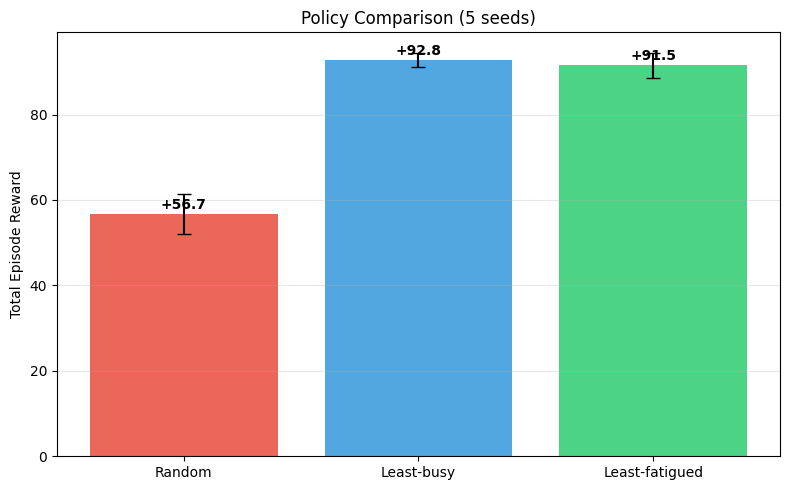

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(policies))
means = [np.mean(multi_results[n]) for n in policies]
stds = [np.std(multi_results[n]) for n in policies]
bars = ax.bar(x, means, yerr=stds, capsize=5, color=["#e74c3c", "#3498db", "#2ecc71"], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(list(policies.keys()))
ax.set_ylabel("Total Episode Reward")
ax.set_title("Policy Comparison (5 seeds)")
ax.grid(True, alpha=0.3, axis="y")

for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f"{m:+.1f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()